In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pratikyuvrajchougule/health-and-lifestyle-data-for-regression/synthetic_health_data.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

https://www.kaggle.com/datasets/pratikyuvrajchougule/health-and-lifestyle-data-for-regression

In [3]:
data = pd.read_csv('/kaggle/input/datasets/pratikyuvrajchougule/health-and-lifestyle-data-for-regression/synthetic_health_data.csv')
df = pd.DataFrame(data)
df.head()

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
0,45.960570,31.996777,5,55.403270,7.300359,0,2.834707,70.542122
1,38.340828,29.623168,6,41.838357,7.012419,1,7.199517,57.244637
2,47.772262,25.298152,5,76.904948,6.028641,1,4.097944,96.333722
3,58.276358,21.765316,2,49.756767,5.802714,1,3.649377,61.321783
4,37.190160,28.491117,2,44.218737,7.912548,0,2.839795,67.175894


## 1. Data Understanding

In [4]:
df.shape

(1000, 8)

In [5]:
df.columns

Index(['Age', 'BMI', 'Exercise_Frequency', 'Diet_Quality', 'Sleep_Hours',
       'Smoking_Status', 'Alcohol_Consumption', 'Health_Score'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   float64
 1   BMI                  1000 non-null   float64
 2   Exercise_Frequency   1000 non-null   int64  
 3   Diet_Quality         1000 non-null   float64
 4   Sleep_Hours          1000 non-null   float64
 5   Smoking_Status       1000 non-null   int64  
 6   Alcohol_Consumption  1000 non-null   float64
 7   Health_Score         1000 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 62.6 KB


In [7]:
df.describe()

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.231985,25.354181,2.888000,69.952977,6.973135,0.499000,3.079377,85.479947
std,11.750591,4.987272,1.995354,14.972061,1.517218,0.500249,2.084564,13.633845
min,1.104792,10.298057,0.000000,19.907497,2.431107,0.000000,-3.592506,29.106017
25%,32.228916,21.968792,1.000000,59.945481,5.903351,0.000000,1.644111,76.430819
50%,40.303607,25.315386,3.000000,69.975151,6.990847,0.000000,3.064261,87.498996
75%,47.775327,28.644411,5.000000,80.527839,8.054595,1.000000,4.489293,99.762644
max,86.232778,40.965538,6.000000,110.265186,11.638962,1.000000,11.105100,100.000000


In [8]:
df.isnull().sum()

Age                    0
BMI                    0
Exercise_Frequency     0
Diet_Quality           0
Sleep_Hours            0
Smoking_Status         0
Alcohol_Consumption    0
Health_Score           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

Age                    1000
BMI                    1000
Exercise_Frequency        7
Diet_Quality           1000
Sleep_Hours            1000
Smoking_Status            2
Alcohol_Consumption    1000
Health_Score            759
dtype: int64

In [11]:
df.corr(numeric_only=True)

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
Age,1.000000,-0.040400,0.011829,-0.016554,0.023491,0.002250,-0.023532,-0.186939
BMI,-0.040400,1.000000,0.007113,-0.039968,0.034498,-0.033797,-0.011069,-0.415147
Exercise_Frequency,0.011829,0.007113,1.000000,-0.021836,0.022106,0.024958,-0.011666,0.245036
Diet_Quality,-0.016554,-0.039968,-0.021836,1.000000,0.009629,0.010283,0.000146,0.680686
Sleep_Hours,0.023491,0.034498,0.022106,0.009629,1.000000,-0.022288,-0.020747,0.269033
Smoking_Status,0.002250,-0.033797,0.024958,0.010283,-0.022288,1.000000,-0.025147,-0.109123
Alcohol_Consumption,-0.023532,-0.011069,-0.011666,0.000146,-0.020747,-0.025147,1.000000,-0.138264
Health_Score,-0.186939,-0.415147,0.245036,0.680686,0.269033,-0.109123,-0.138264,1.000000


## 2. Data Cleaning

In [12]:
# Converting datatype
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].round(2)

print(df[float_cols].head())

     Age    BMI  Diet_Quality  Sleep_Hours  Alcohol_Consumption  Health_Score
0  45.96  32.00         55.40         7.30                 2.83         70.54
1  38.34  29.62         41.84         7.01                 7.20         57.24
2  47.77  25.30         76.90         6.03                 4.10         96.33
3  58.28  21.77         49.76         5.80                 3.65         61.32
4  37.19  28.49         44.22         7.91                 2.84         67.18


## 3. EDA 

### 3.1) Univariate Analysis
We will create an prediction. We will use the BMI and Diet_Quality variables.

Text(0.5, 1.0, 'Distribution of Age')

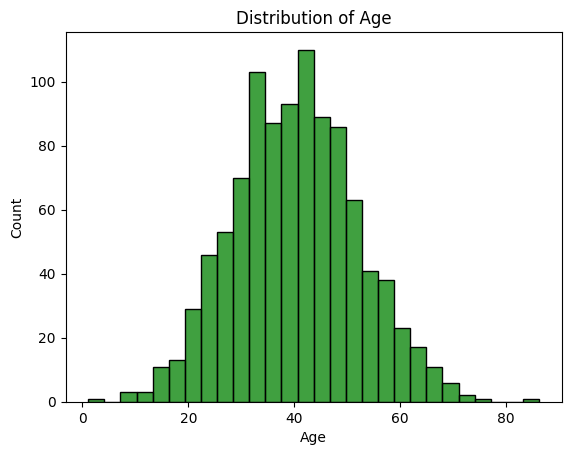

In [13]:
sns.histplot(df["Age"],color='green',edgecolor='black')
plt.title('Distribution of Age')

Text(0.5, 1.0, 'Distribution of BMI')

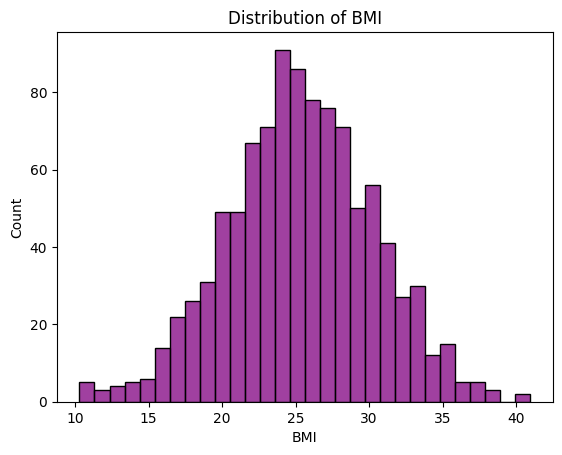

In [14]:
sns.histplot(df["BMI"],bins=30,color='purple',edgecolor='black')
plt.title('Distribution of BMI')

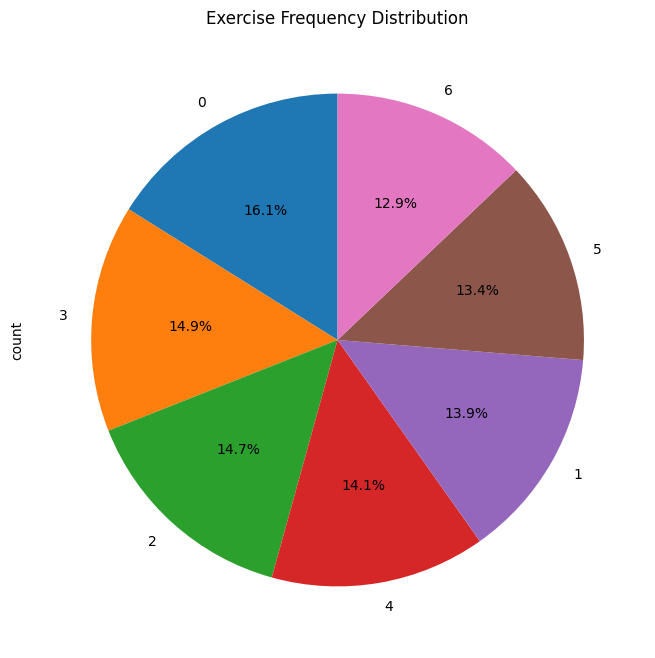

In [15]:
plt.figure(figsize=(8,8))
df["Exercise_Frequency"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    shadow=False
)
plt.title("Exercise Frequency Distribution")
plt.show()

So we have a nearly equal distribution of the 6 types exercise frequency..


Text(0.5, 1.0, 'Distribution of Diet Quality')

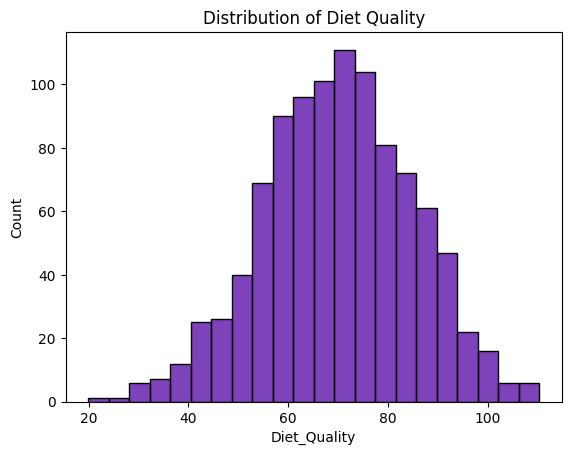

In [16]:
sns.set_palette("plasma")

sns.histplot(df['Diet_Quality'], edgecolor='black')
plt.title('Distribution of Diet Quality')

Text(0.5, 1.0, 'Distribution of Sleepng Hours')

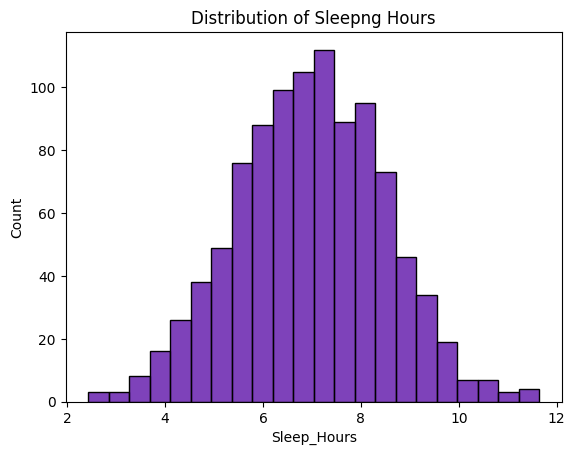

In [17]:
sns.set_palette("plasma")

sns.histplot(df['Sleep_Hours'], edgecolor='black')
plt.title('Distribution of Sleepng Hours')

Text(0.5, 1.0, 'Distribution of Smoking Status')

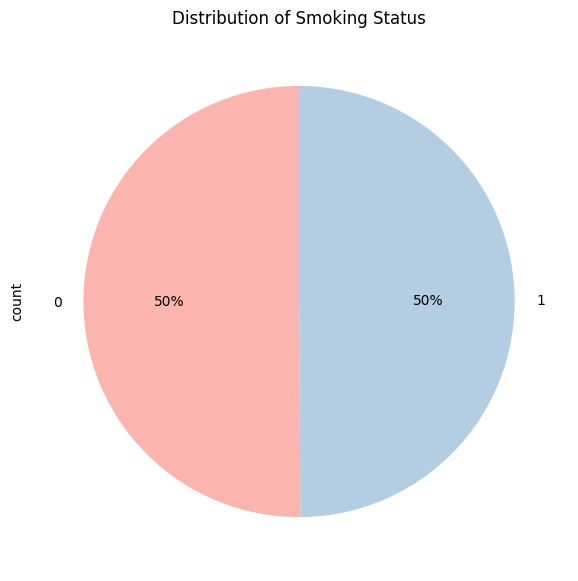

In [18]:
# Getting the counts of each different Watering Frequencies
Smoking_Status_counts = df['Smoking_Status'].value_counts()
fig,ax = plt.subplots(figsize=(7,7))

Smoking_Status_counts.plot.pie(
    ax=ax,
    autopct='%1.0f%%',  # For percentage
    startangle=90,      # For better view
    colors=plt.get_cmap('Pastel1').colors  # For Colors

)

ax.set_title('Distribution of Smoking Status')


Text(0.5, 1.0, 'Distribution of Alcohol Consumption')

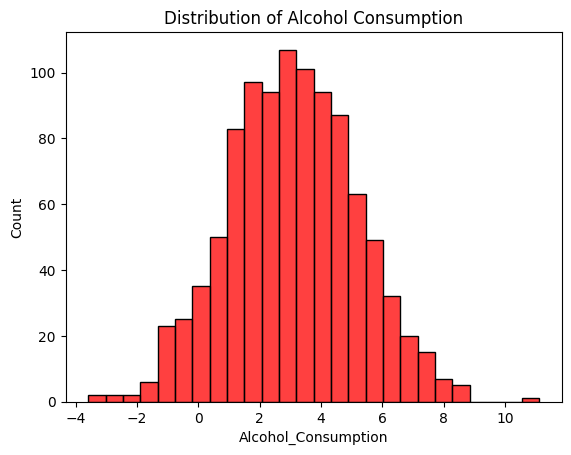

In [19]:
sns.histplot(df['Alcohol_Consumption'],color='red',edgecolor='black')
plt.title('Distribution of Alcohol Consumption')

Text(0.5, 1.0, 'Distribution of Health Score')

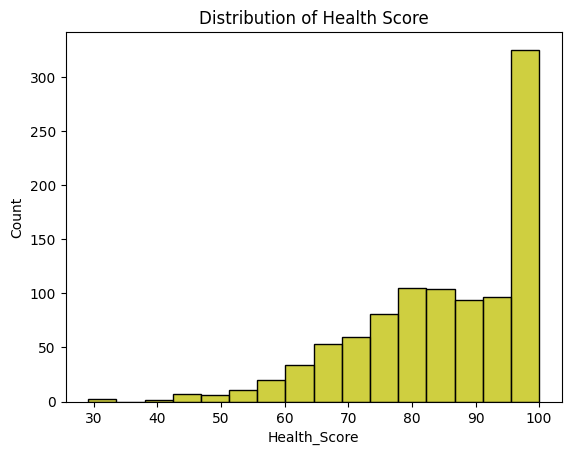

In [20]:
sns.histplot(df['Health_Score'],color='y',edgecolor='black')
plt.title('Distribution of Health Score')

* The health score is skewed to the left.<br>
Now we know that the health score is high, we can look at graphs between the two types of data that show an inverse relationship.

<Axes: xlabel='Health_Score'>

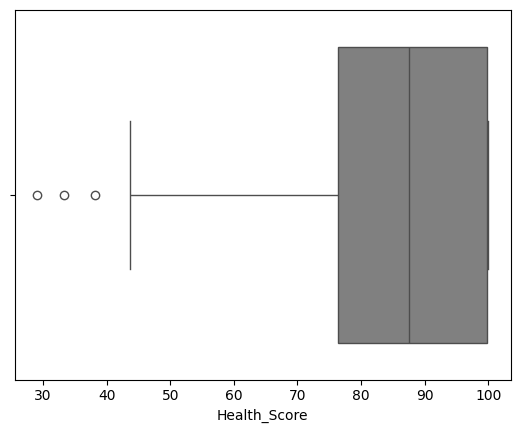

In [21]:
# Let's draw a boxplot for our dependent variable Health_Score:
sns.boxplot(x = df['Health_Score'],color='gray')

* Our Box-Plot Chart is skewed to the left.
* Our health score is between 75-100 and is positive.
* We have 3 extreme values that are not in our range, between 30-40.

### 3.2 Multivariate Analysis
It's answer some other questions and check what are the features that directly affect the Health Score.

In [22]:
focused_Vs = df.loc[:, ["BMI", "Diet_Quality"]]
# The loc function works with the indexes of the columns. We have created a data frame consisting of two variables.

focused_Vs

,BMI,Diet_Quality
0,32.00,55.40
1,29.62,41.84
2,25.30,76.90
3,21.77,49.76
4,28.49,44.22
...,...,...
995,30.35,60.67
996,24.87,66.53
997,20.59,69.82
998,24.18,70.72


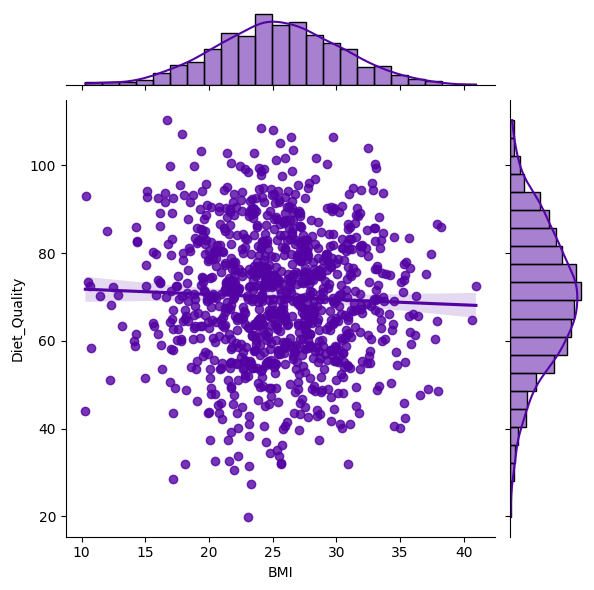

In [23]:
# To see both the scatter plot and the graph of the related variables together:
sns.jointplot(x = "BMI",
              y = "Diet_Quality",
              data = focused_Vs,
              kind="reg")

* BMI and Diet_Quality have a very weak negative relationship.

In [24]:
focused_Vs = df.loc[:, ["Age", "Sleep_Hours"]]
# The loc function works with the indexes of the columns. We have created a data frame consisting of two variables.

focused_Vs

,Age,Sleep_Hours
0,45.96,7.30
1,38.34,7.01
2,47.77,6.03
3,58.28,5.80
4,37.19,7.91
...,...,...
995,36.63,8.47
996,61.57,5.36
997,47.69,8.64
998,33.15,7.94


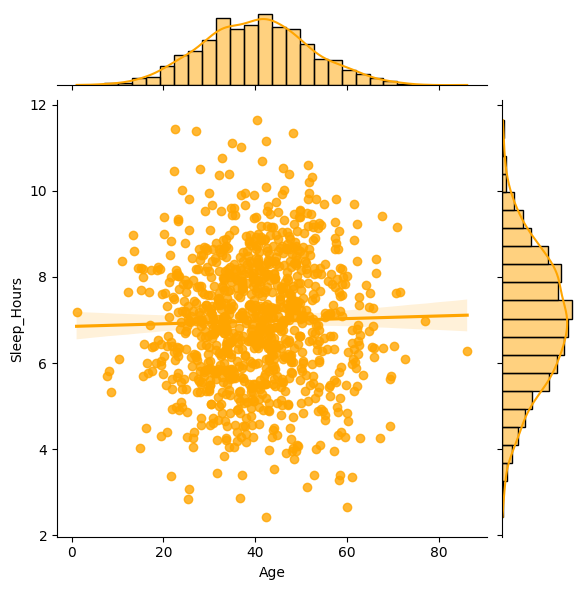

In [25]:
# To see both the scatter plot and the graph of the related variables together:
sns.jointplot(x = "Age",
              y = "Sleep_Hours",
              data = focused_Vs,
              kind="reg",
              color='orange')

The dots are widely scattered, which tells us:
* People of the same age can have very different sleep hours.
* Age alone does not strongly determine sleep hours.

This suggests:
As age increases, sleep hours tend to increase a little

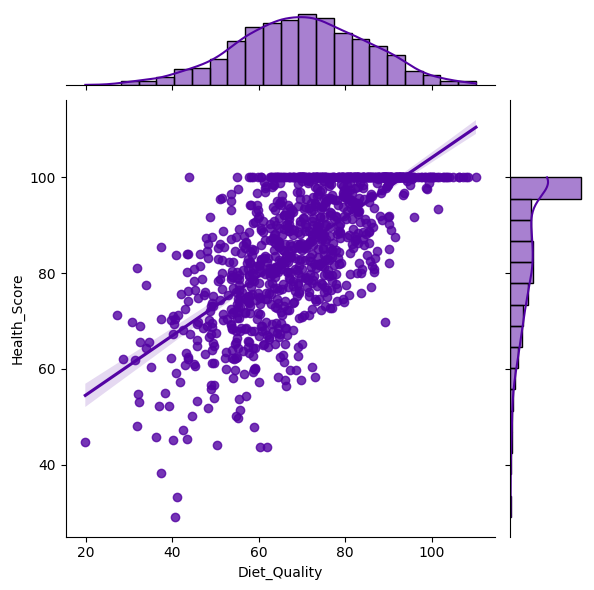

In [26]:
focused_Vs = df.loc[:, ["Diet_Quality", "Health_Score"]]

sns.jointplot(x = "Diet_Quality",
              y = "Health_Score",
              data = focused_Vs,
              kind="reg")

**What can we conclude from this graphics?**

* The diet quality and health score are definitely positively correlated.

## 4. Data Preprocessing


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [28]:
X = df.drop("Health_Score", axis=1)
y = df["Health_Score"]

In [29]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [30]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Model Selection & Hyperparameter Tuning

In [31]:
from sklearn.model_selection import GridSearchCV,cross_val_score, KFold

In [32]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 6. Machine Learning

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
model = LinearRegression()

In [35]:
# Cross Validation with default values (Model Evaluation)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')

print("Cross Validation R² Scores:", cv_scores)
print("Mean R² Score:", cv_scores.mean())

Cross Validation R² Scores: [0.86294254 0.83190801 0.8202875  0.84955498 0.80081223]
Mean R² Score: 0.8331010529530838


In [36]:
# Nothing has trained here
param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False]
}

grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid,
    cv=kf,
    scoring='r2'
)

Note: After successfully training of all the model parameters, GridSearchCV automatically returns the best model parameter

In [37]:
grid.fit(X_train_scaled, y_train) # Training Model whose accuracy is the highest among all. Refer above Note

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'copy_X': True, 'fit_intercept': True}
Best CV Score: 0.8331010529530838


In [38]:
results = pd.DataFrame(grid.cv_results_)

In [39]:
best_lr = grid.best_estimator_ 

In [40]:
best_lr

LinearRegression()

In [41]:
print(grid.best_params_) # Shows Best Input Parameter
print(results['mean_test_score'].max()) # Shows the Best one accuracy

{'copy_X': True, 'fit_intercept': True}
0.8331010529530838


In [42]:
y_pred = best_lr.predict(X_test_scaled)

In [43]:
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.8089859148513014
MSE: 37.24085762323358
